In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

# Fase III: VISUALIZACIÓN DE LOS DATOS

In [11]:
df_hrlimpio=pd.read_csv("files/hr_clean.csv")

In [12]:
import importlib
import src.soporte_visualizaciones as sv

importlib.reload(sv)

vis = sv.Visualizaciones(df_hrlimpio)
import warnings
warnings.filterwarnings('ignore')

# FOCO: Económico

- **Objetivo general:** *Analizar si la deserción de empleados se relaciona con variables económicas asociadas a la estructura laboral,antiguedad y experiencia, y a la carga de trabajo.*

In [6]:
# ----- BLOQUE 1: Salario -----

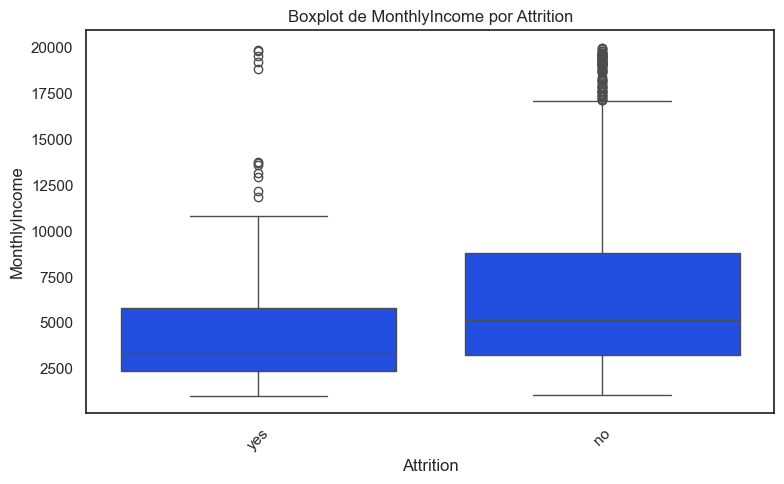

In [13]:
vis.boxplot(
    x="Attrition",
    y="MonthlyIncome"
)

In [8]:
df_hrlimpio["salary_cat"] = pd.qcut(df_hrlimpio["MonthlyIncome"], q=3, labels=["bajo", "medio", "alto"])

In [ ]:
tabla_salario = pd.crosstab(df_hrlimpio["salary_cat"], df_hrlimpio["Attrition"], normalize="index")

tabla_salario["% rotacion"] = (tabla_salario["Yes"] * 100).round(1).astype(str) + "%"

tabla_salario["Semaforo"] = tabla_salario["Yes"].apply(semaforo)

tabla_salario[["yes", "% rotacion", "Semaforo"]]

KeyError: 'salary_cat'

En esta gráfica se observa la comparación entre el salario mensual (MonthlyIncome) según la desercion (Attrition) de los empleados. Los empleados que abandonan la empresa (yes) presentan, en general, `salarios más bajos` que los que permanecen (no). Aun así, existen valores atípicos en ambos grupos, lo que indica que el salario no es el único factor que influye en la rotación.

In [15]:
# ----- BLOQUE 2: Estructura laboral -----

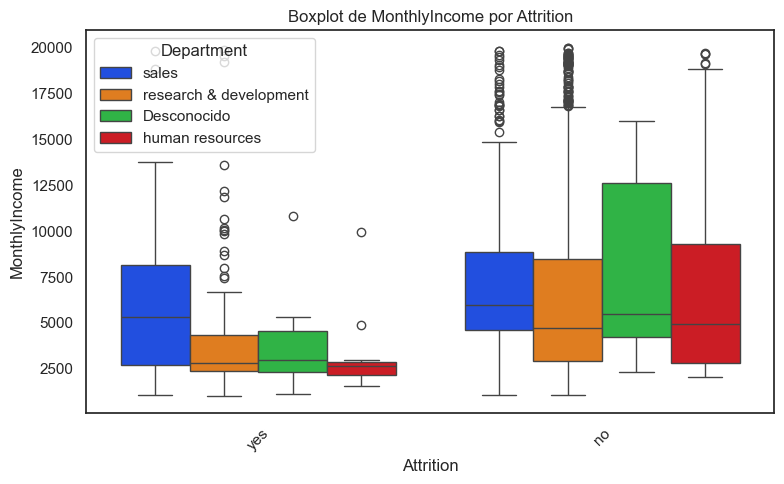

In [16]:
vis.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    hue="Department"
)

A nivel de outputs, este gráfico muestra que:

- Los empleados que no se van (no) tienen, en general, mayores salarios que los que sí se van (yes); que tienen `salarios más bajos, en todos los departamentos`.
- Research & Development y Sales concentran los salarios más altos y mayor variabilidad, especialmente entre los que permanecen.
- Human Resources presenta los salarios más bajos y una distribución más homogénea.
- Existen outliers en todos los grupos, lo que indica que hay empleados con salarios altos que también abandonan la empresa.

    - Se analizarán los valores nulos para identificar patrones, evaluar su impacto en el dataset y definir una estrategia de imputación o eliminación adecuada.

In [17]:
desconocidos=pd.crosstab(df_hrlimpio["Department"],df_hrlimpio["Attrition"],normalize="index")

In [18]:
desconocidos

Attrition,no,yes
Department,,
Desconocido,0.655172,0.344828
human resources,0.809524,0.190476
research & development,0.865815,0.134185
sales,0.797267,0.202733


El Departmento con etiqueta “desconocido” tiene la mayor tasa de rotación: 34% se va (yes), frente a:
- ~13% en R&D
- ~20% en Sales
- ~19% en HR

Lo que significa que los valores nulos no son aleatorios, están asociados a un comportamiento concreto como la posible falta de información o problemas en el registro de datos.

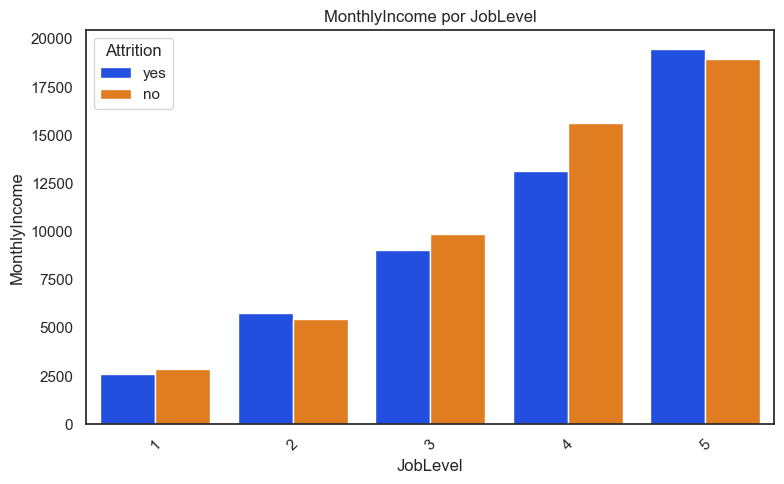

In [19]:
vis.barplot(
    x="JobLevel",
    y="MonthlyIncome",
    hue="Attrition"
)

In [25]:
df_hrlimpio[df_hrlimpio["JobLevel"] == 3]["salary_cat"].value_counts() # Acabo de detectar que el nivel 3 es engañoso, ese 60% viene solo de 5 personas, por lo tanto, el nivel 3 no es tan problematico como parecia

KeyError: 'salary_cat'

In [ ]:
tabla_sal_nivel = pd.crosstab([df_hrlimpio["JobLevel"], df_hrlimpio["salary_cat"]], df_hrlimpio["Attrition"], normalize="index")

tabla_sal_nivel["% rotacion"] = (tabla_sal_nivel["yes"] * 100).round(1).astype(str) + "%"

tabla_sal_nivel["Semaforo"] = tabla_sal_nivel["yes"].apply(semaforo)

tabla_sal_nivel[["yes", "% rotacion", "Semaforo"]]

A nivel de outputs, este gráfico muestra que:

- La rotación es significativamente mayor en los niveles más bajos, especialmente en el `nivel 1`, y disminuye a medida que aumenta el nivel del puesto. Esto confirma que los perfiles más junior son los que más abandonan la empresa (26%).

    - La alta rotación en niveles junior no solo se debe a una mayor propensión a abandonar la empresa, sino también a que en estos niveles `se concentran la mayor parte de la plantilla`. Esto amplifica el impacto de la rotación en perfiles de entrada.”

- La rotación no solo se concentra en la entrada (nivel 1), sino que reaparece en niveles intermedios (`nivel 3`), lo que sugiere problemas en la progresión profesional.

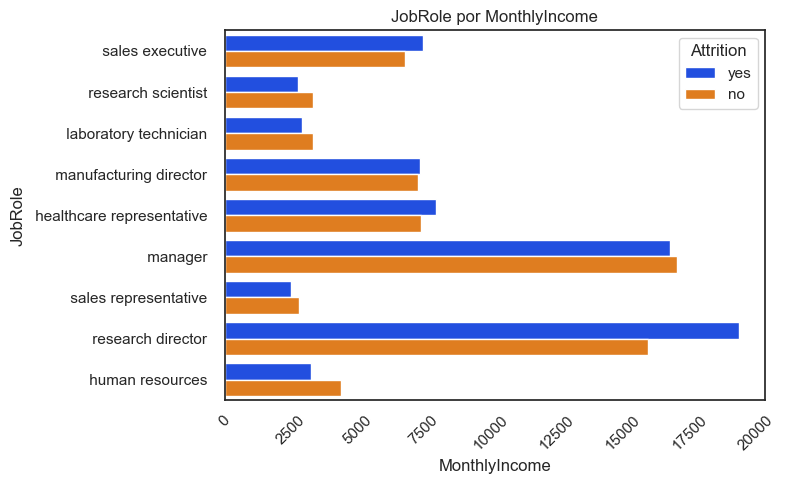

In [22]:
vis.barplot(
    x="MonthlyIncome",
    y="JobRole",
    hue="Attrition"
)

In [23]:
pd.crosstab(df_hrlimpio["JobRole"], df_hrlimpio["Attrition"], normalize="index")

Attrition,no,yes
JobRole,,
healthcare representative,0.931298,0.068702
human resources,0.769231,0.230769
laboratory technician,0.760618,0.239382
manager,0.950980,0.049020
manufacturing director,0.931034,0.068966
research director,0.975000,0.025000
research scientist,0.839041,0.160959
sales executive,0.825153,0.174847
sales representative,0.602410,0.397590


La gráfica muestra que el salario mensual `varía claramente según el puesto de trabajo`. Además, en varios puestos se observa que los empleados que abandonan la empresa presentan salarios medios inferiores a los de quienes permanecen, especialmente en puestos operativos y comerciales, `siendo crítica` en `Sales Representative` (casi 40%).

In [ ]:
# ----- BLOQUE 3: Carga de trabajo -----

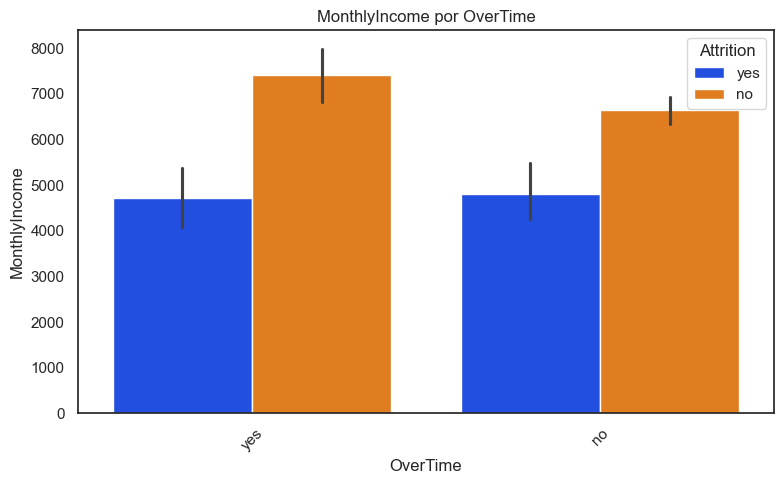

In [ ]:
vis.barplot(
    x="OverTime",
    y="MonthlyIncome",
    hue="Attrition"
)

A nivel de outputs, este gráfico muestra que:
- Quienes se van (yes) cobran menos, con o sin horas extra.
- Los `empleados con menor salario que además realizan horas extra` presentan mayor tendencia a abandonar la empresa.

In [ ]:
# ----- BLOQUE 3: Antigüedad y experiencia -----

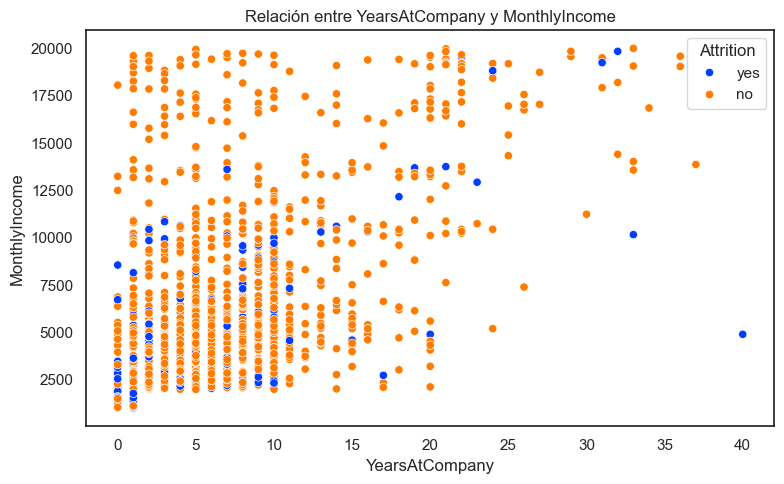

In [ ]:
vis.scatterplot(
    x="YearsAtCompany",
    y="MonthlyIncome",
    hue="Attrition"
)

La mayor fuga de talento ocurre en los `primeros años del empleado en la empresa, donde coinciden menor salario, menor experiencia y peores condiciones`.


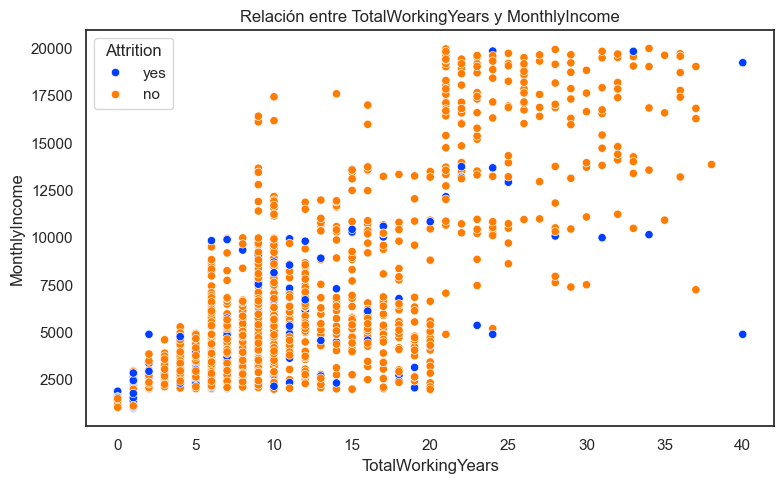

In [ ]:
vis.scatterplot(
    x="TotalWorkingYears",
    y="MonthlyIncome",
    hue="Attrition"
)

Text(0, 0.5, 'Número de empleados')

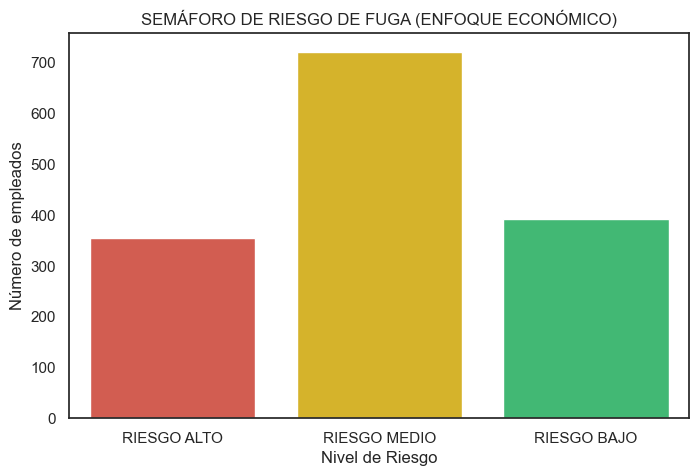

In [28]:

import seaborn as sns
import matplotlib.pyplot as plt

orden = ["RIESGO ALTO", "RIESGO MEDIO", "RIESGO BAJO"]

plt.figure(figsize=(8,5))

sns.countplot(
    data=df_hrlimpio,
    x="Semaforo_Economico",
    order=orden,
    palette=["#E74C3C", "#F1C40F", "#2ECC71"]
)

plt.title("SEMÁFORO DE RIESGO DE FUGA (ENFOQUE ECONÓMICO)")
plt.xlabel("Nivel de Riesgo")
plt.ylabel("Número de empleados")

La rotación se concentra en `empleados con menor experiencia y menor salario`, mientras que los perfiles más experimentados presentan mayor estabilidad.

# Resultados del enfoque: Económico = Patrones

1. El análisis muestra que la rotación no es homogénea, sino que se concentra principalmente en `perfiles junior`, donde alcanza alrededor del 26%, frente a menos del 10% en niveles senior.
    - El principal foco de rotación está en perfiles junior dentro de roles comerciales y operativos, `especialmente en Sales Representative`, , con casi un 40% de abandono, lo que indica un problema estructural en estas posiciones.
2. Desde el punto de vista salarial, observamos que los empleados que se marchan tienden a tener `salarios más bajos`; sin embargo, el salario por sí solo no explica completamente la rotación, ya que `también` existe abandono en `niveles altos`.

**Conclusión: La `deserción` está asociada a perfiles con `menor salario, menor experiencia y menor antigüedad`, pero `también` a `factores estructurales del puesto`, por lo que requiere estrategias de retención específicas.**

------------------------------------------------------------------------------------

ENFOQUE SATISFACION

In [ ]:
from src.Clase_Bienestar import TalentSatisfactionAnalyzer

In [ ]:
auditoria = TalentSatisfactionAnalyzer(df_hrlimpio)

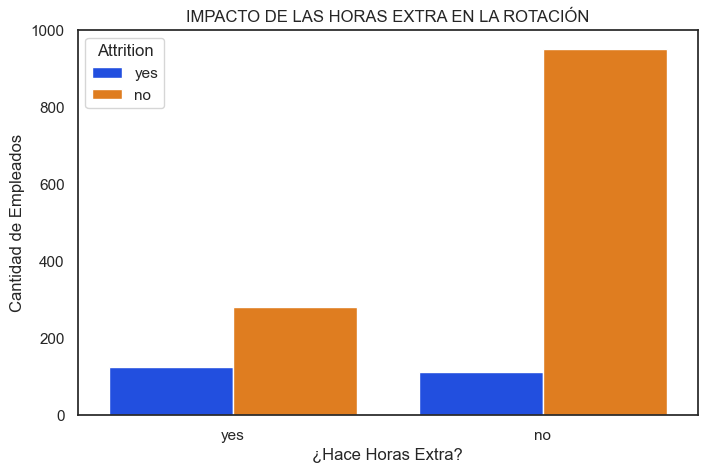

---REPORTE HORAS EXTRA VS ROTACIÓN ---
Personal con Horas Extra (no): 10.5% de fuga
Personal con Horas Extra (yes): 30.9% de fuga


In [ ]:
auditoria.graficar_horas_extra()

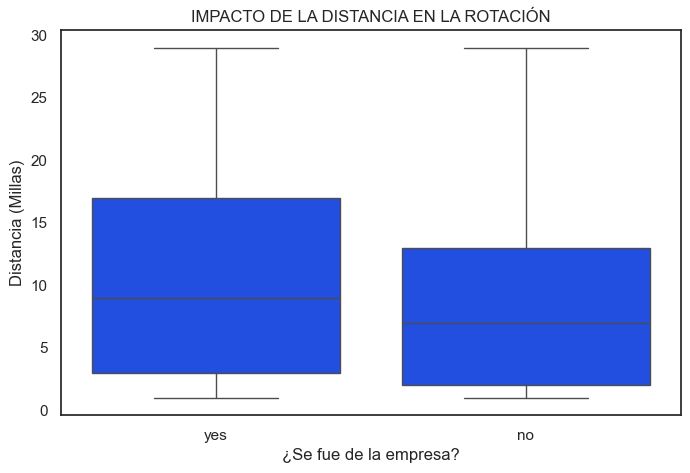

--- REPORTE DE DISTANCIA CASA-TRABAJO ---
Grupo que permanece: 7.0 millas
Grupo que renunció: 9.0 millas


In [ ]:
auditoria.graficar_distancia()

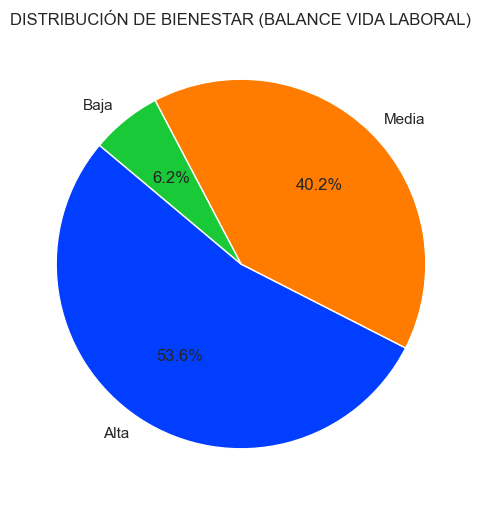

--- REPORTE DE BIENESTAR ---
Nivel Alta: 53.6% (788 empleados)
Nivel Media: 40.2% (591 empleados)
Nivel Baja: 6.2% (91 empleados)


In [ ]:
auditoria.Balance_vida_laboral()

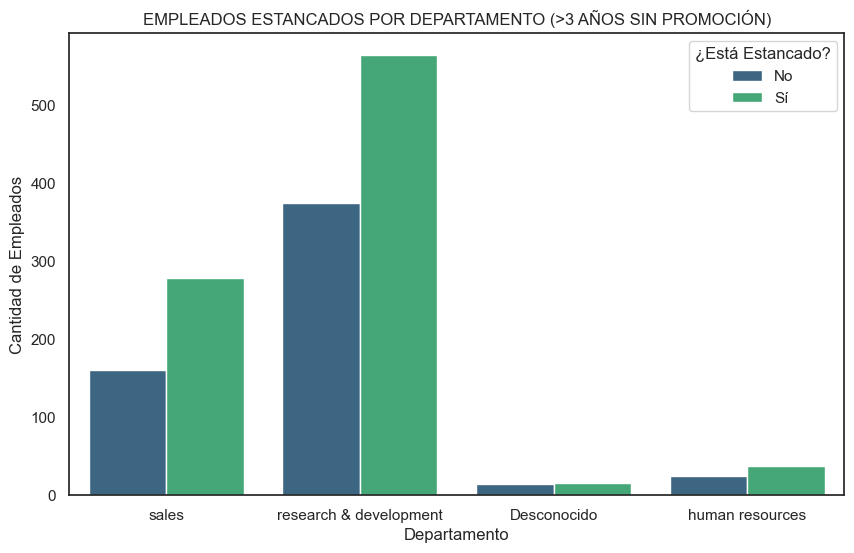

--- REPORTE DE ESTANCAMIENTO POR DEPARTAMENTO ---
DEPARTAMENTO              | ESTANCADOS         | ANTIGUEDAD   | EN EL ROL
DESCONOCIDO               |  15 de  29 (51.7%) |   5.0 años  |   2.0 años
HUMAN RESOURCES           |  38 de  63 (60.3%) |   5.0 años  |   2.0 años
RESEARCH & DEVELOPMENT    | 564 de 939 (60.1%) |   5.0 años  |   3.0 años
SALES                     | 279 de 439 (63.6%) |   6.0 años  |   3.0 años


In [ ]:
auditoria.graficar_estancamiento_por_depto()

c:\Users\Janira\OneDrive\Documentos\adalab\proyectos\modulo 3\proyecto-da-promo-65-modulo-3-team-2\src\Clase_Bienestar.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=self.df, x="Nivel_Entorno", palette=["#E63946", "#FFB703", "#2A9D8F"])


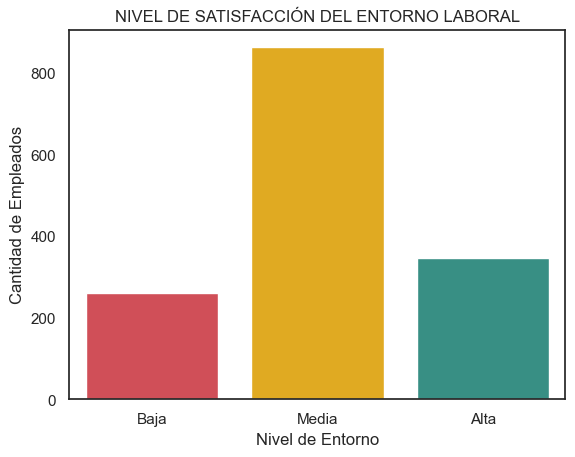

--- REPORTE DE SATISFACCIÓN DE ENTORNO ---
Nivel Baja: 261 empleados (Puntaje medio: 6.0)
Nivel Media: 862 empleados (Puntaje medio: 8.0)
Nivel Alta: 347 empleados (Puntaje medio: 10.0)


In [ ]:
auditoria.analizar_satisfaccion_entorno()

El peligro de las Horas Extra:
El personal que trabaja de más tiene una probabilidad de renunciar tres veces mayor que quienes tienen una jornada normal. El agotamiento es la causa número uno de fuga de talento.
 
El factor "Estancamiento"
Gran parte de los empleados en departamentos clave como Ventas y Recursos Humanos se sienten estancados. Llevan en promedio 5 o 6 años en la empresa, pero se han quedado "congelados" en el mismo rol demasiado tiempo.
 
Distancia y Entorno:
Pequeños detalles suman; los que se van suelen vivir más lejos y tenemos a un grupo considerable (261 personas) con una satisfacción de entorno muy baja que debemos mejorar.
 
En resumen: Aunque la mayoría (53%) tiene un bienestar alto, no podemos confiarnos. Si queremos retener a los mejores, debemos reducir las horas extra, revisar los planes de carrera para que la gente no se sienta estancada y cuidar el ambiente de trabajo. ¡Si arreglamos el estancamiento y el exceso de horas, bajaremos la rotación drásticamente!

 En resumen: Aunque la mayoría (53%) tiene un bienestar alto, A Bc no debe confiarse. Si quiere retener a los mejores, deben reducir las horas extra, revisar los planes de carrera para que la gente no se sienta estancada y cuidar el ambiente de trabajo. ¡Si mejoran situaciones de  estancamiento y el exceso de horas, bajareian la rotación drásticamente!

 
Informe Ejecutivo
Visión General
El análisis revela que la organización posee una base sólida de bienestar (53% nivel alto), pero enfrenta riesgos estructurales que comprometen la retención del talento clave. La deserción no es un fenómeno aislado, sino el resultado de factores operativos y de falta de dinamismo en la carrera profesional.
 
1. Ejes de Riesgo: Bienestar y Agotamiento
 
Impacto de las Horas Extra: Se identifica un riesgo crítico de fatiga; el personal con jornadas extendidas tiene una probabilidad de renuncia tres veces mayor que el resto. El agotamiento físico y mental aparece como el principal detonante de la fuga de talento.
 
Estancamiento Profesional: Existe una parálisis en el crecimiento dentro de departamentos como Ventas y RR.HH. Los empleados promedian de 5 a 6 años de antigüedad en la empresa, pero llevan entre 2 y 3 años congelados en el mismo rol, lo que genera una percepción de falta de futuro.
 
Logística y Entorno: El factor de proximidad es relevante; se observa que el grupo que renuncia suele recorrer más millas de distancia entre su casa y el trabajo en comparación con quienes permanecen. Esto, sumado a un entorno laboral que no satisface a un grupo considerable de empleados, acelera la rotación.
 
2. Patrones Económicos y Estructurales
 
Vulnerabilidad en Perfiles Junior: La rotación se concentra en etapas tempranas de la carrera (26%), alcanzando niveles críticos en roles como Sales Representative, con casi un 40% de abandono. Esto señala un problema en la estructura de estos puestos específicos.
 
Dinámica Salarial: Si bien la deserción está asociada a salarios más bajos y menor experiencia, también existe abandono en niveles altos, lo que confirma que el salario por sí solo no garantiza la lealtad si no hay un equilibrio con el bienestar.
 
Conclusión Estratégica
La deserción está vinculada a una combinación de menor antigüedad, salarios iniciales y factores estructurales del puesto. Para reducir la rotación drásticamente, la empresa debe evolucionar hacia un modelo que priorice:
 
Reducción de la carga horaria para mitigar el agotamiento.
 
Activación de planes de carrera que rompan el estancamiento de quienes llevan años en el mismo rol.
 
Estrategias diferenciadas para perfiles junior, asegurando que el entorno y la distancia no se conviertan en barreras insalvables.
 
En resumen: Si se logra transformar el estancamiento en movimiento y el exceso de horas en eficiencia, la organización blindará su capital humano de manera sostenible.
 

 
Aquí tienes 4 propuestas estratégicas basadas directamente en tus hallazgos de "5-6 años de antigüedad con 2-3 en el mismo rol":
1. Programas de "Job Rotation" (Rotación de Puestos)
Dado que el estancamiento ocurre tras 2 o 3 años en el mismo rol, la empresa debe fomentar el movimiento interno.
En qué consiste: Permitir que empleados de Ventas o RR.HH. pasen temporadas cortas (proyectos de 3 meses) en otros departamentos o funciones dentro de su misma área.
Por qué funciona: Rompe la monotonía sin necesidad de un ascenso inmediato, refresca el interés del empleado y lo prepara para futuras promociones.
2. Micro-Promociones y "Career Pathing" Claro
Si la estructura es muy plana y no hay vacantes para ascender, se deben crear niveles intermedios.
En qué consiste: En lugar de esperar 5 años para ser "Gerente", crear roles como Senior, Mentor o Líder de Proyecto. Cada salto debe ir acompañado de un ajuste salarial (aunque sea pequeño) y nuevas responsabilidades.
Por qué funciona: Ataca directamente el dato de los "2-3 años congelados". El empleado siente que su carrera se mueve, aunque no cambie de departamento.
3. Presupuesto para Desarrollo y "Upskilling"
Para los perfiles Junior y los estancados, el aprendizaje es un motivador crítico.
En qué consiste: Asignar un presupuesto anual o tiempo laboral (ejemplo: 4 horas a la semana) para que el empleado tome cursos certificados.
Por qué funciona: Si el empleado siente que está aprendiendo habilidades nuevas que aumentan su valor profesional, la sensación de "estar estancado" desaparece porque su perfil sigue creciendo.
4. Plan de Incentivos por Objetivos (En lugar de por Horas)
Para eliminar la cultura de las horas extra, hay que cambiar el enfoque del esfuerzo al resultado.
En qué consiste: Implementar bonos de desempeño vinculados a metas cumplidas en tiempo eficiente. Si terminas tu trabajo en 35 horas con alta calidad, recibes el mismo beneficio (o más) que el que se queda 50 horas.
Por qué funciona: Premia la eficiencia y castiga el "presentismo". Esto reduce el agotamiento de forma natural porque el empleado tiene un incentivo real para irse a casa temprano.
Resumen para tu propuesta final:
"Para blindar la retención, propongo complementar la flexibilidad laboral con un Plan de Movilidad Interna que rompa el estancamiento de los 2-3 años, y un Modelo de Gestión por Resultados que elimine la necesidad cultural de realizar horas extra, priorizando la salud mental y el crecimiento constante del colaborador."
 
 
Optimización de Jornada y Teletrabajo: Establecer un límite saludable de 48 horas semanales para frenar el agotamiento y ofrecer opciones de teletrabajo prioritarias para quienes recorren más millas, eliminando así dos de los principales disparadores de renuncia.
Plan de Carrera contra el Estancamiento: Implementar "micro-pasos" o rotaciones de puesto para romper el ciclo de los 2-3 años en el mismo rol, asegurando que el personal con antigüedad (5-6 años) mantenga una perspectiva de crecimiento constante.
 